**Estimation of Obesity Levels Based On Eating Habits and Physical Condition**

8/26/2019



Estimation of Obesity Levels Based On Eating Habits and Physical Condition  [Dataset]. (2019). UCI Machine Learning Repository. https://doi.org/10.24432/C5H31Z.


---

This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. The data contains 17 attributes and 2111 records, the records are labeled with the class variable NObesity (Obesity Level), that allows classification of the data using the values of Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II and Obesity Type III.

---
**The Problem** - What are the most influential eating habits and physical conditions that predict an individual's specific obesity level, and how can we build an interpretable model to accurately classify these levels?


**Importance** - Obesity has become a major health issue around the world. The health risks, metabolic complications, and required medical interventions for Obesity Type I are vastly different from those for Obesity Type III. By predicting the specific level early, healthcare professionals can prescribe highly targeted interventions.


**Expected Outcome** - A high-performance predictive model: we will build and compare multiple classifiers (KNeighbours, Decision Tree, Random Forest, XGBoost). The expected outcome is a model with high weighted F1-score and accuracy (targeting around 98%) that reliably distinguishes between all seven classes.

| Variable                       | Type        | Description                            |
| ------------------------------ | ----------- | -------------------------------------- |
| Gender                         | Categorical | Gender                                 |
| Age                            | Continuous  | Age                                    |
| Height                         | Continuous  | Height                                 |
| Weight                         | Continuous  | Weight                                 |
| family_history_with_overweight | Binary      | Family history of overweight           |
| FAVC                           | Binary      | Frequent high-calorie food consumption |
| FCVC                           | Integer     | Vegetable consumption frequency        |
| NCP                            | Continuous  | Number of main meals per day           |
| CAEC                           | Categorical | Eating between meals                   |
| SMOKE                          | Binary      | Smoking habit                          |
| CH2O                           | Continuous  | Daily water intake                     |
| SCC                            | Binary      | Calorie monitoring                     |
| FAF                            | Continuous  | Physical activity frequency            |
| TUE                            | Integer     | Technology use time                    |
| CALC                           | Categorical | Alcohol consumption                    |
| MTRANS                         | Categorical | Transportation used                    |
| NObeyesdad                     | Categorical | Obesity level                          |


Importing libraries that will be used later.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading the dataset and previewing its first few rows.




In [ ]:
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


Checking for missing values in each column.

In [ ]:
df.isna().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


**Counting the total number of duplicate rows in the dataset, then dropping them.**

In [ ]:
df.duplicated().sum()

np.int64(24)

In [ ]:
df = df.drop_duplicates()

**Checking each columns current data type.**

In [ ]:
df.dtypes

,0
Gender,object
Age,float64
Height,float64
Weight,float64
family_history_with_overweight,object
FAVC,object
FCVC,float64
NCP,float64
CAEC,object
SMOKE,object


**Separating categorical and numerical columns for feature distinction.**

In [ ]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols
numerics = ['float64']

num_cols = df.select_dtypes(include=numerics)

**Encoding all categorical variables into numerical labels.**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
df_encoded = df.copy()
df_encoded['NObeyesdad'] = le.fit_transform(df_encoded['NObeyesdad'])

In [ ]:
for cols in df[cat_cols]:
  print(f'{cols}: {df[cols].unique()}')

Gender: ['Female' 'Male']
family_history_with_overweight: ['yes' 'no']
FAVC: ['no' 'yes']
CAEC: ['Sometimes' 'Frequently' 'Always' 'no']
SMOKE: ['no' 'yes']
SCC: ['no' 'yes']
CALC: ['no' 'Sometimes' 'Frequently' 'Always']
MTRANS: ['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']
NObeyesdad: ['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']


In [ ]:
df_encoded['Gender']=df_encoded['Gender'].map({'Female':0,'Male':1})
binary_encoding = ['family_history_with_overweight','FAVC','SMOKE','SCC']
for i in df_encoded[binary_encoding]:
  df_encoded[i] = df_encoded[i].map({'no':0,'yes':1})
df_encoded.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.0,1.62,64.0,1,0,2.0,3.0,Sometimes,0,2.0,0,0.0,1.0,no,Public_Transportation,1
1,0,21.0,1.52,56.0,1,0,3.0,3.0,Sometimes,1,3.0,1,3.0,0.0,Sometimes,Public_Transportation,1
2,1,23.0,1.80,77.0,1,0,2.0,3.0,Sometimes,0,2.0,0,2.0,1.0,Frequently,Public_Transportation,1
3,1,27.0,1.80,87.0,0,0,3.0,3.0,Sometimes,0,2.0,0,2.0,0.0,Frequently,Walking,5
4,1,22.0,1.78,89.8,0,0,2.0,1.0,Sometimes,0,2.0,0,0.0,0.0,Sometimes,Public_Transportation,6


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
order = ['no', 'Sometimes', 'Frequently','Always']
encoder = OrdinalEncoder(categories=[order])
df_encoded['CAEC'] = encoder.fit_transform(df[['CAEC']])
df_encoded['CALC'] = encoder.fit_transform(df[['CALC']])
df_encoded.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1.0,0,2.0,0,0.0,1.0,0.0,Public_Transportation,1
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1.0,1,3.0,1,3.0,0.0,1.0,Public_Transportation,1
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1.0,0,2.0,0,2.0,1.0,2.0,Public_Transportation,1
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1.0,0,2.0,0,2.0,0.0,2.0,Walking,5
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1.0,0,2.0,0,0.0,0.0,1.0,Public_Transportation,6


In [ ]:
df_encoded = pd.get_dummies(df_encoded, columns=["MTRANS"], drop_first=True, dtype=int)

**Previewing the encoded dataset, values seem to be transformed correctly.**

In [ ]:
df_encoded.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,NObeyesdad,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1.0,0,2.0,0,0.0,1.0,0.0,1,0,0,1,0
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1.0,1,3.0,1,3.0,0.0,1.0,1,0,0,1,0
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1.0,0,2.0,0,2.0,1.0,2.0,1,0,0,1,0
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1.0,0,2.0,0,2.0,0.0,2.0,5,0,0,0,1
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1.0,0,2.0,0,0.0,0.0,1.0,6,0,0,1,0


**Generating summary statistics for numerical features.**

In [ ]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,24.353090,1.702674,86.858730,2.421466,2.701179,2.004749,1.012812,0.663035
std,6.368801,0.093186,26.190847,0.534737,0.764614,0.608284,0.853475,0.608153
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.915937,1.630178,66.000000,2.000000,2.697467,1.590922,0.124505,0.000000
50%,22.847618,1.701584,83.101100,2.396265,3.000000,2.000000,1.000000,0.630866
75%,26.000000,1.769491,108.015907,3.000000,3.000000,2.466193,1.678102,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


The dataset primarily comprises young adults (mean age 24, range 14–61) with substantial weight variability (mean 86.9 kg, standard deviation 26.2). Physical activity frequency (FAF) is notably low on average (mean 1.0 on a 0–3 scale, with 25% of values near 0), whereas vegetable consumption (FCVC) is relatively high (mean 2.4 on a 1–3 scale). Technology usage (TUE) and daily water intake (CH2O) show moderate averages, with all features having complete data (count = 2087 across all columns).

Some conclusions we can make from these findings:

With a mean age of 24.3 and a median of 22.8 (75th percentile at 26), this is not a general population sample—it's predominantly young adults. This matters because obesity drivers and intervention strategies differ greatly for this age group compared to middle-aged or elderly populations.

The population of this dataset is already primarily obese/overweight. Calculating a rough BMI from the mean values gives approximately 30.1, which falls into the obese category. This confirms that the dataset is not balanced across all classes, it has an overrepresentation of overweight/obese individuals.


**Visualizing histograms of numerical colums.**

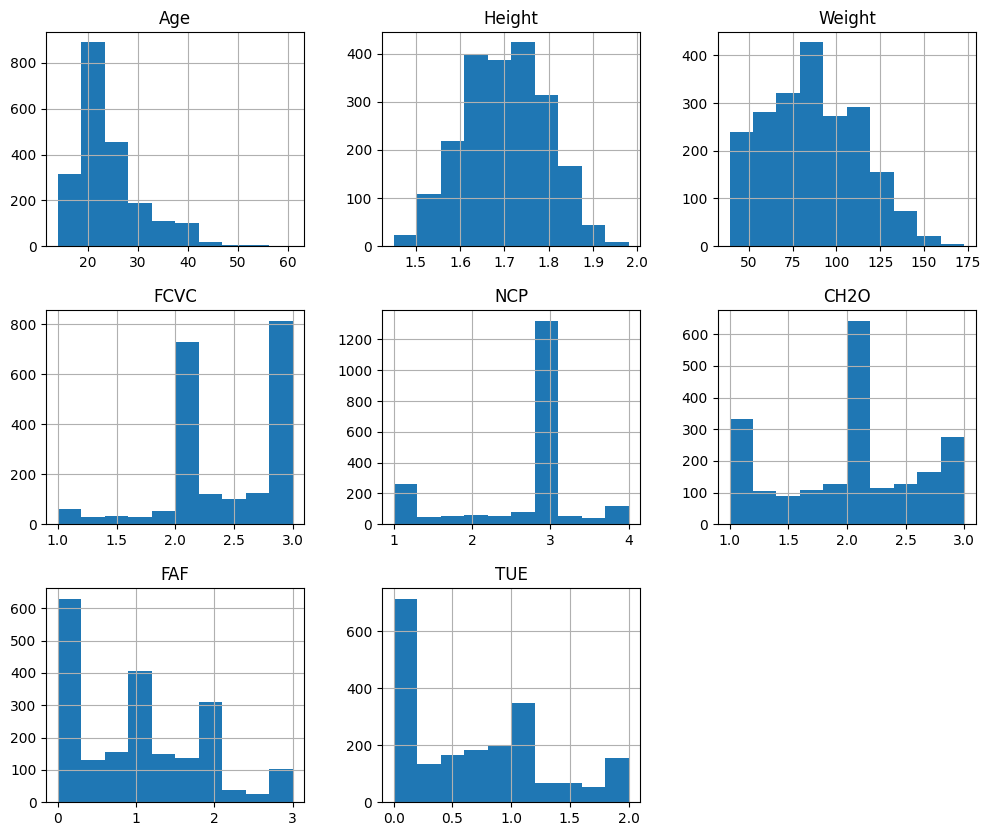

In [ ]:
num_cols.hist(figsize=(12,10))
plt.show()

**Age:** The distribution is heavily right-skewed (positively skewed). The vast majority of individuals are clustered between 14 and 30 years old, with a sharp drop-off after age 30 and a long, thin tail extending up to age 61. The peak is around the late teens to early 20s. The model will have less data to learn patterns for older individuals, so predictions for those over 40 may be less reliable.

**Height:** The distribution appears roughly bell-shaped (normal), centered around 1.70 meters, with a slight left skew. The range spans from 1.45 m to 1.98 m. Since height is strongly correlated with weight (as seen earlier), this feature will be useful for calculating BMI-like patterns, but its normal distribution means it won't introduce bias into the model.

**Weight:** The distribution is bimodal or slightly right-skewed, with a primary peak around 60 – 80 kg and a secondary, smaller peak around 100 – 120 kg. The full range extends from 39 kg to 173 kg, with a long tail toward heavier weights. The bimodal shape likely reflects the distinct obesity classes present in the target variable. This distribution validates the dataset's utility for multi-class classification, as there is enough representation across different weight ranges to differentiate between obesity levels.

**FCVC:** This is a discrete, left-skewed distribution on a 1 – 3 scale. The highest bar is at 3 (high vegetable intake), followed by 2, with very few individuals at 1. Most participants report eating vegetables frequently. However, because the variable has only three levels, the histogram lacks fine granularity.

**NCP:** A multimodal discrete distribution centered around 3 meals per day, with meaningful counts at 2 and 4 as well. Very few individuals report only 1 meal. The majority of the population follows a standard three-meal pattern. The presence of individuals with 2 or 4 meals allows for some variation, but the limited spread (1 – 4) means this feature may have moderate predictive power at best.

**CH2O:** A relatively uniform or flat distribution across the 1 – 3 scale, with a slight peak at 2 (moderate water intake). The counts are fairly balanced among the three levels. Water intake varies naturally across the population, but the uniform spread suggests it does not strongly differentiate between obesity classes on its own.

**FAF:** A strongly right-skewed distribution on a 0 – 3 scale. The tallest bar is at 0 (no physical activity), followed by 1, with progressively fewer individuals at 2 and 3. The 25th percentile is near 0.12, confirming that a quarter of the population is essentially sedentary. The majority of participants are physically inactive or only minimally active. The sharp drop-off at higher activity levels means the model will have abundant data for "low activity" cases but limited data for "high activity" cases.

**TUE:** A right-skewed distribution on a 0 – 2 scale. The highest frequency is at 0 (low technology usage), with decreasing counts at 1 and 2. However, the spread is not extremely skewed—there is reasonable representation across all levels.


**Visualizing categorical colums with countplot.**

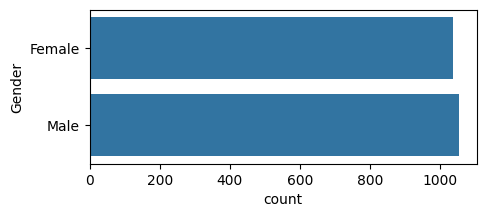

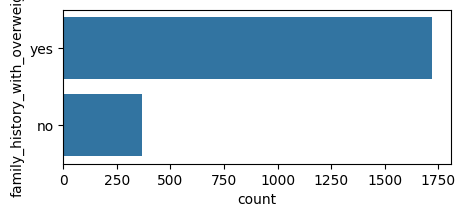

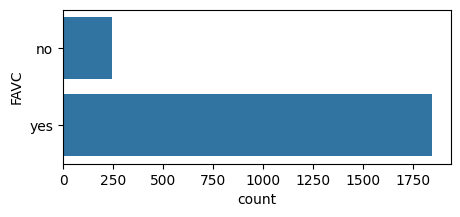

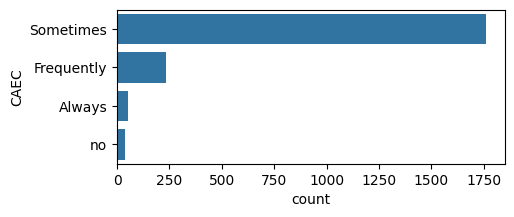

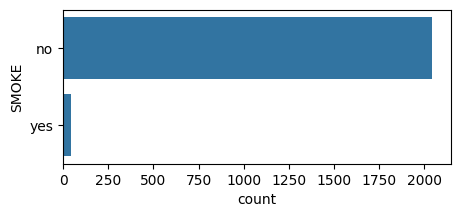

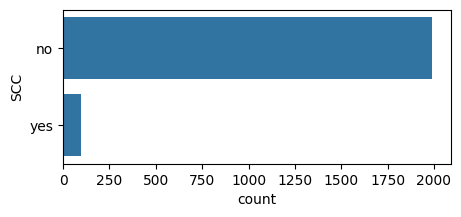

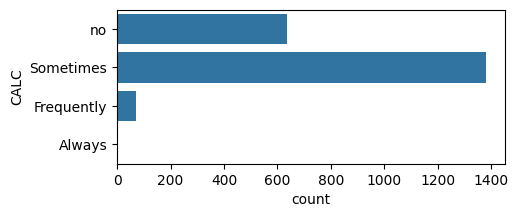

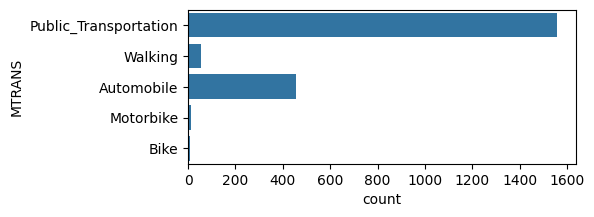

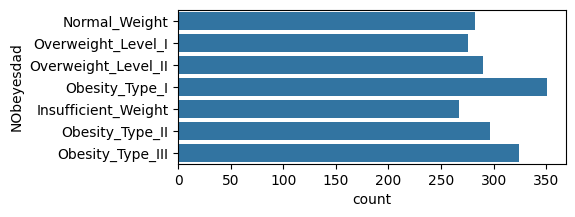

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(5, 2))
    sns.countplot(df[col])
    plt.show()

**Gender:** The dataset has an almost perfectly balanced gender distribution, with only a slight female majority (approximately 49% female, 51% male). The difference is negligible.


**Family History With Overweight:** The countplot shows a heavily imbalanced feature, with approximately 1,700 individuals reporting a family history and only 300 reporting no family history.


**FAVC (Do you usually eat vegetables in your meals?):** The countplot shows more individuals answering "yes" (frequent consumption) than "no" , with roughly 1800 "yes" and 250 "no".

**CAEC (Do you eat any food between meals?):** The vast majority (round 1750) report eating between meals "Sometimes" , while only about 250 report "Frequently", and a mere 50 each report "Always" or "no" (never snacking). This feature is heavily imbalanced toward the "Sometimes" category, which means CAEC will likely have limited predictive power as a standalone feature—most individuals fall into a single dominant group. The model will struggle to differentiate between obesity levels based on snacking frequency alone, as there is insufficient representation of the rarer categories ("Always" and "no") to learn meaningful patterns.

**SMOKE (Do you smoke?):** More than 2000 counts for "no" and less than a 100 for "yes". This imbalance means that it's going to be harder to predict the link between obesity and smoking habits.

**SCC (Do you monitor your calories daily):** Almost 2000 for "no" and around 100 for "yes". Again, not a perfect sample pool to make predictions from.

**CALC (How often do you drink alcohol):** Around 1300 for "Sometimes", a little more than 600 for "no", less than 100 for "Frequently" and almost zero for "Always". Similar situation to CAEC, but this time the model could make better predictions if we base it on drinkers and non-drinkers, since the split will be closer to even.

**MTRANS (Which transportation do you usually use?):** More than 1500 for "Public Transportation", around 500 for "Automobile", less than 100 for "Walking" and almost 0 for "Motorbike" and "Bike".

**NObeyesdad (Obesity level):** "Obesity Type I" is the most common class with 340 records, "Insufficient Weight" is the least common with 250 records. The remaining five classes each have approximately 290 records, with "Obesity Type III" slightly higher at 320. The target distribution is relatively well-balanced, with class frequencies ranging from 250 to 340. No class overwhelmingly dominates, which is ideal for multi-class classification.

**Detecting outliers in numerical features using the IQR method.**

In [ ]:
for col in num_cols:
    Q1 = num_cols[col].quantile(0.25)
    Q3 = num_cols[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    print(col, ((num_cols[col] > upper) | (num_cols[col] < lower)).sum())

Age 167
Height 1
Weight 1
FCVC 0
NCP 577
CH2O 0
FAF 0
TUE 0


**Age:** 167 outliers — reflects the right-skewed distribution observed earlier, with a long tail toward older ages (40 – 61). These are likely legitimate older individuals, not data errors.

**NCP (number of meals):** 577 outliers — a massive count, likely because the distribution is discrete (1 – 4 meals) and the IQR rule flags values like 4 as extreme relative to the lower quartile. This suggests the feature is naturally skewed/discrete and these "outliers" are valid, not erroneous.

**Height and Weight:** only 1 outlier each — indicating very clean, realistic biological measurements.

**FCVC, CH2O, FAF, TUE:** 0 outliers — these features have compact distributions with no extreme values.

**Visualizing outliers for Age and NCP using boxplots.**

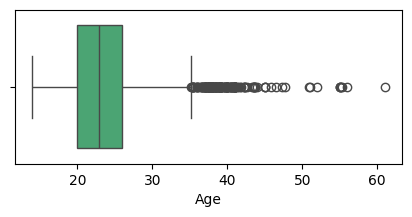

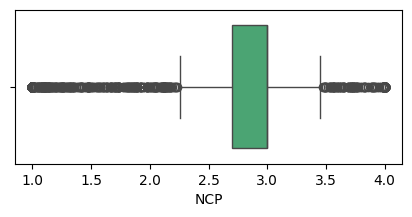

In [ ]:
for col in ['Age', 'NCP']:
    plt.figure(figsize=(5, 2))
    sns.boxplot(df[col], orient='y', color='mediumseagreen')
    plt.show()

The plots confirm the IQR findings: Age shows numerous upper outliers (points beyond 40 years), reflecting the right-skewed distribution with older individuals as valid but rare cases. NCP exhibits extreme outlier counts at the value 4, but since this feature is discrete (1 – 4 meals), the boxplot visually demonstrates that the IQR method is inappropriate here—the "outliers" are simply the natural upper end of a limited ordinal scale, not erroneous data points.


**Visualizing paired plots between each category to find relationships.**

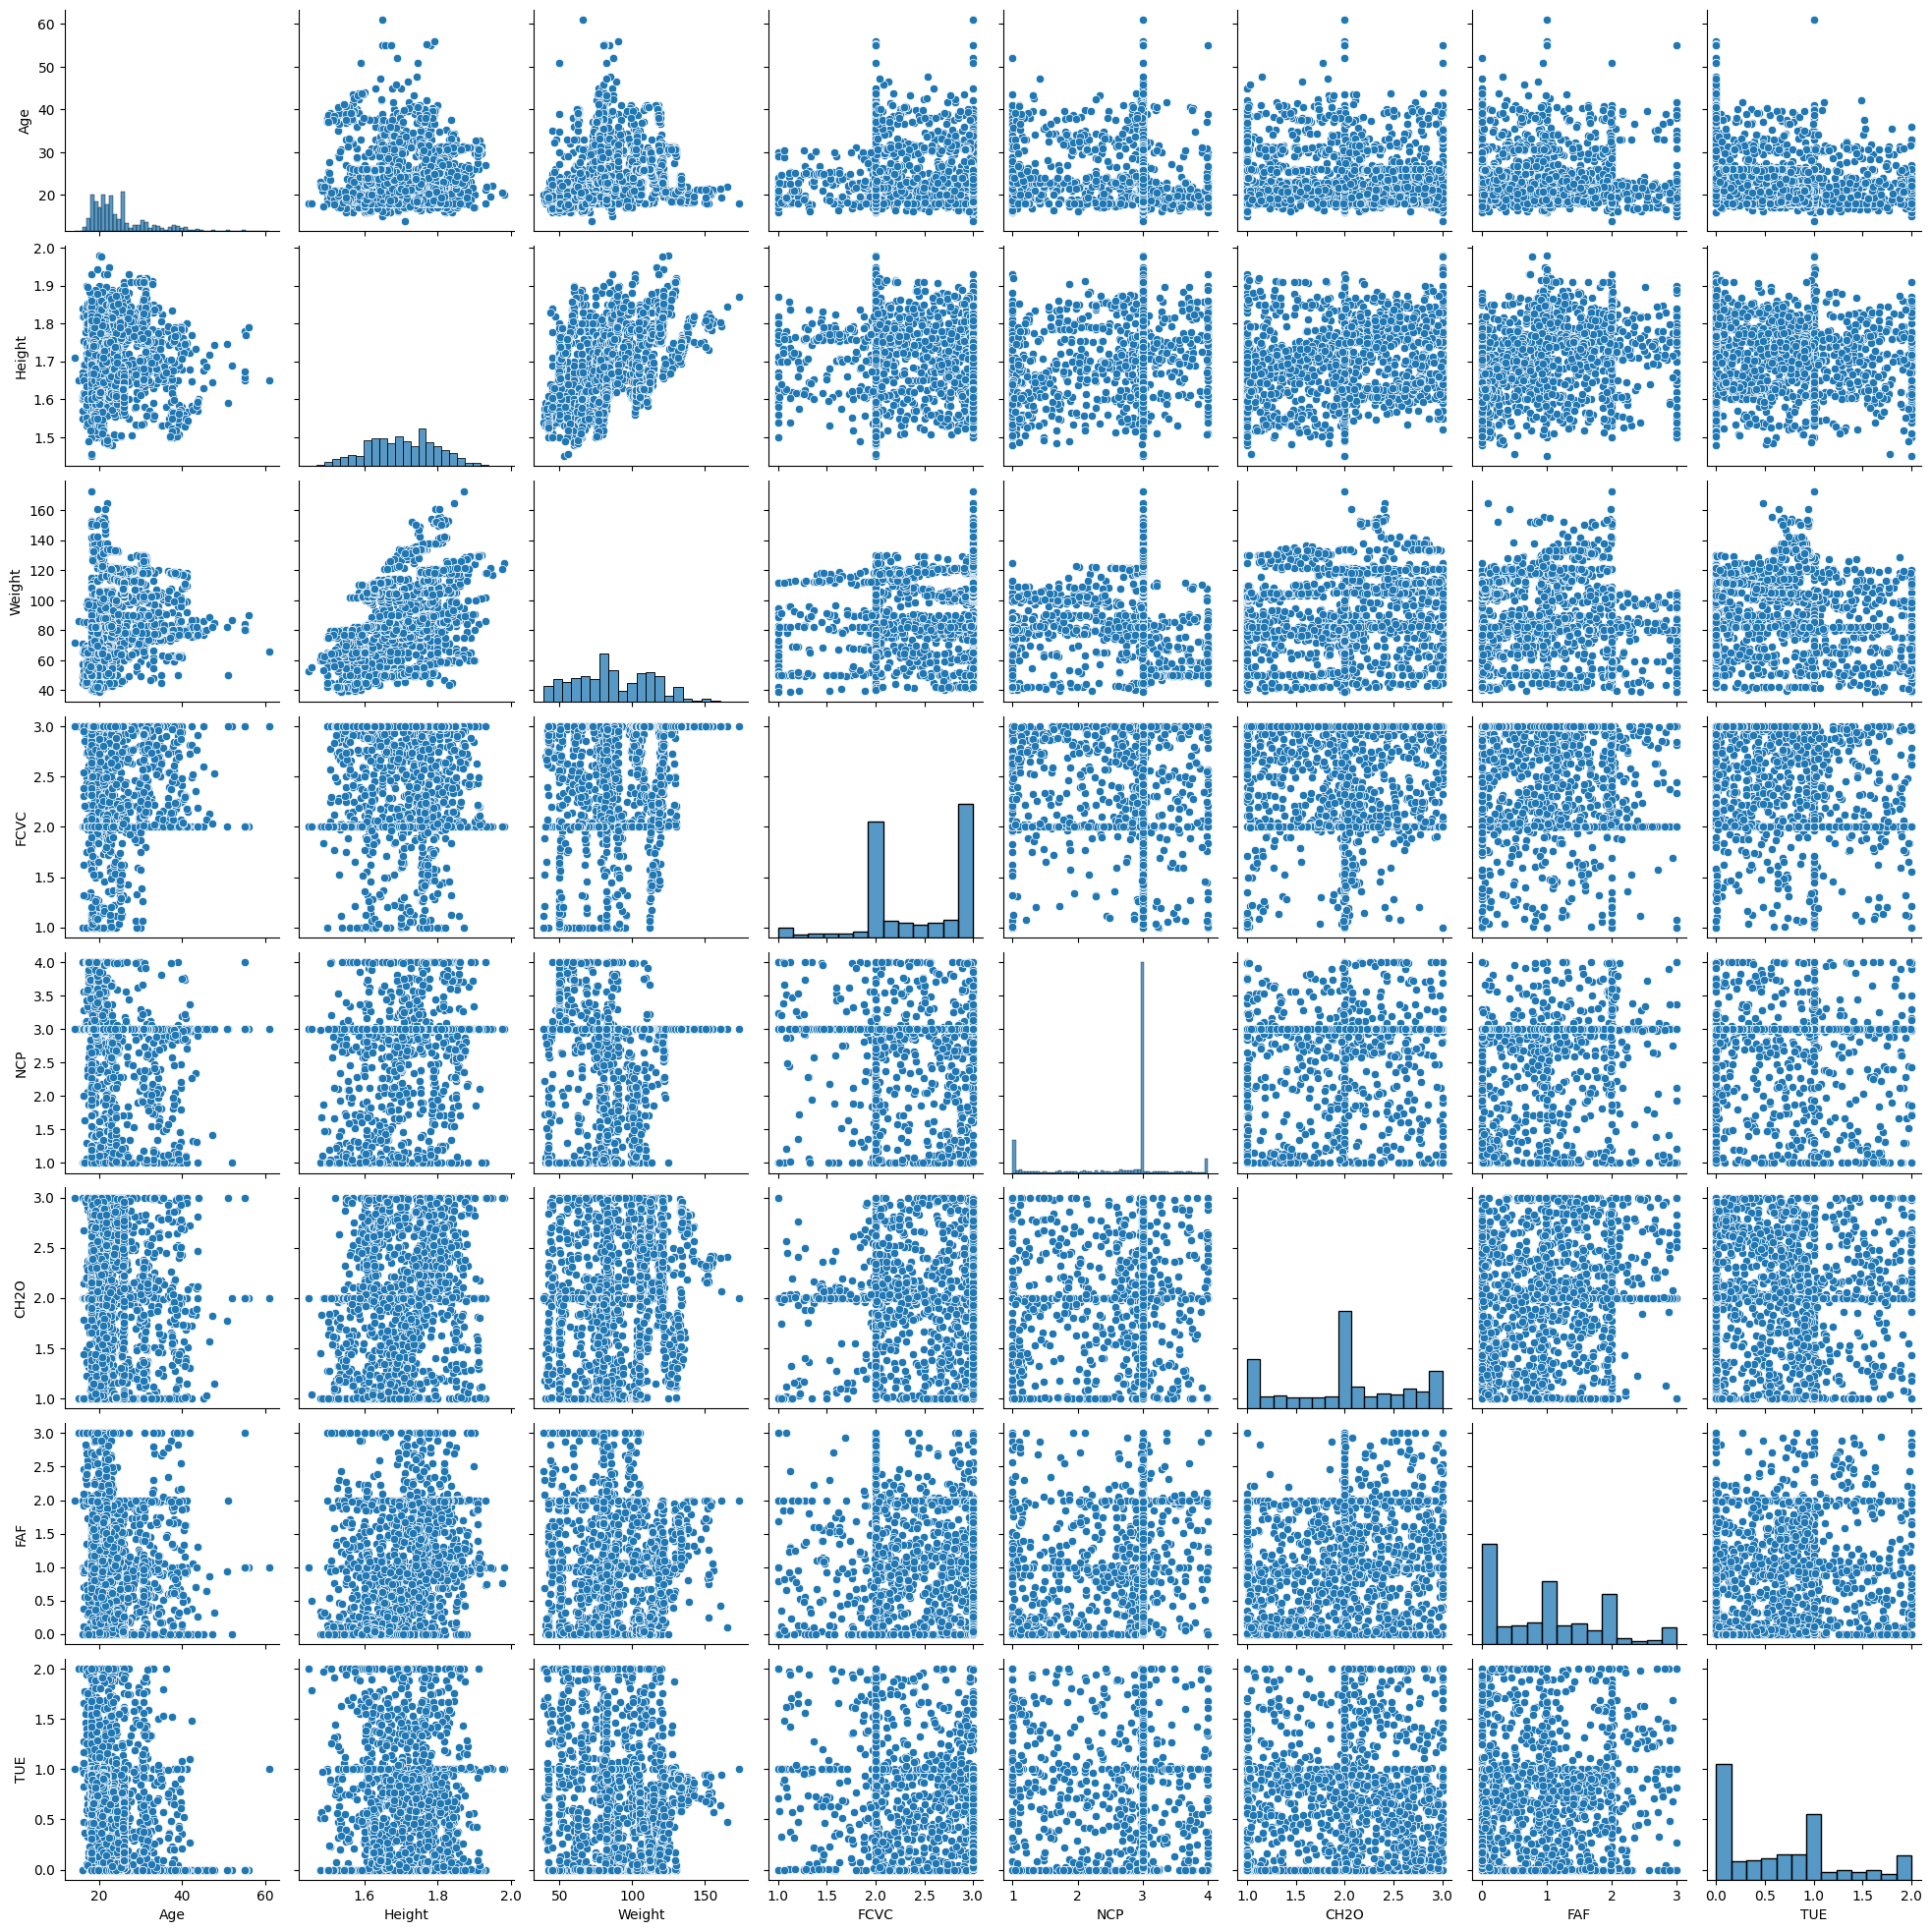

In [ ]:
sns.pairplot(num_cols)

After inspecting the pair plots, we found a pattern behaviour in the pair plot between "Weight" and "Height" features. We can analyze it in relation to Obesity Levels.

**Scatter plot between weight and height with obesity level as the hue.**

<Axes: xlabel='Weight', ylabel='Height'>

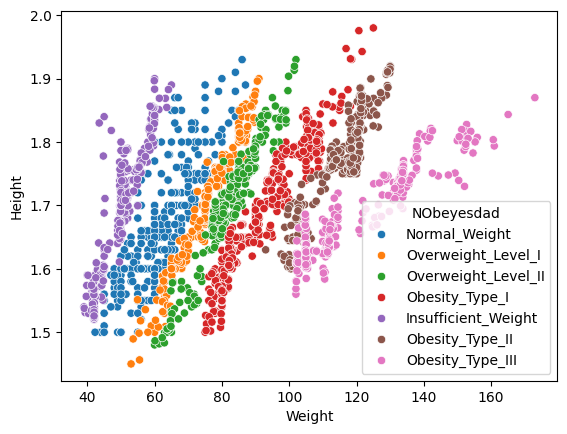

In [ ]:
sns.scatterplot(data = df, x = 'Weight', y = 'Height', hue = 'NObeyesdad')

As we can see, the relationship between weight and height is positive, but not in a complete 1-1 scale, due to the nature of the datasets population. Height does not correlate to most obesity levels, but there is a sharp decline of obesity type III counts at 1.8 meters of height, implying a somewhat negative correlation.

**Visualizing obesity levels distribution by gender.**

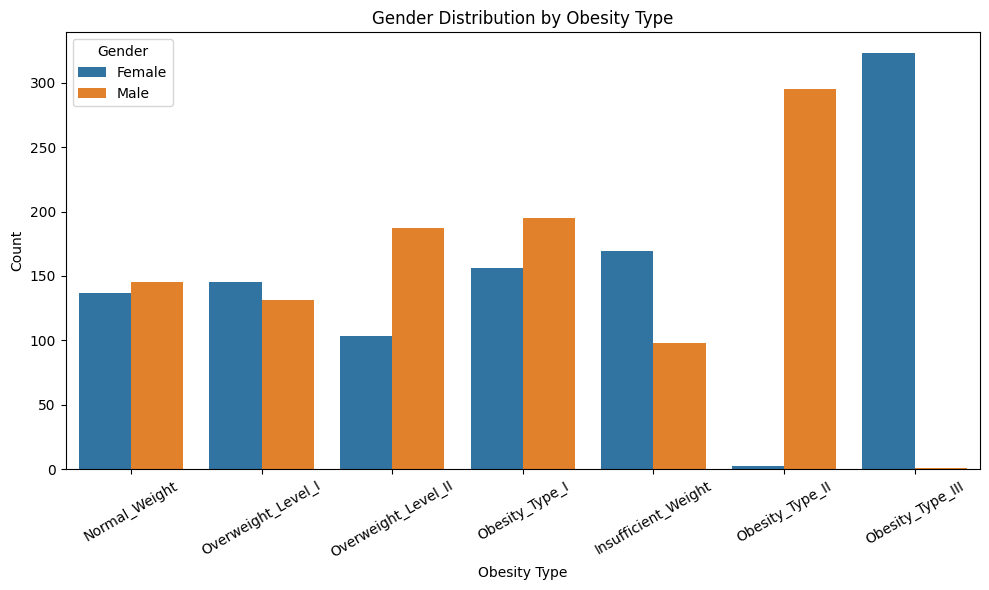

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df,x="NObeyesdad",hue="Gender")
plt.title("Gender Distribution by Obesity Type")
plt.xlabel("Obesity Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()


*  On lower ends, female gender dominates the count with around 175 in Insufficient Weight category, while male gender only had around a 100.

*   No severe desparities between genders on borderline healthy weights (Normal weight - Overweight level 1) with the count being a bit lower than 150 on all ocassions.

*   Significant proportional rise of males in the middle levels. Overweight level II males count being around 200 and females around 100, while obesity type I males count is still aorund 200, females around 150.

*  Obesity type II is heavily dominated by males, 300 males vs only around 5 females. But inversily, obesity type III is heavily dominated by females, 325 females vs around 5 males.

The most striking revelation here is that gender interacts strongly with obesity severity, perhaps due to different biological thresholds, behavioral patterns, or socioeconomic factors. For instance, males may plateau at Type II, while females who reach severe obesity are more likely to progress to Type III.



**Encoded correlations between each category.**

In [ ]:
df_encoded.corr()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,NObeyesdad,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
Gender,1.000000,0.050641,0.626748,0.163176,0.113492,0.061220,-0.271575,0.077863,-0.074564,0.045501,0.095129,-0.102435,0.189471,0.022356,-0.010574,0.014699,0.057541,0.045731,-0.163790,0.043530
Age,0.050641,1.000000,-0.031748,0.198160,0.200379,0.063895,0.013572,-0.055823,-0.092097,0.091261,-0.044058,-0.117959,-0.148202,-0.302927,0.045565,0.238308,0.003291,0.019867,-0.555532,-0.060906
Height,0.626748,-0.031748,1.000000,0.457468,0.232258,0.180694,-0.040363,0.227806,-0.058001,0.054326,0.220487,-0.137078,0.293584,0.041808,0.135756,0.038700,0.028580,-0.011323,-0.084407,0.037122
Weight,0.163176,0.198160,0.457468,1.000000,0.492969,0.274655,0.216574,0.092149,-0.300271,0.024369,0.203823,-0.205409,-0.056490,-0.079351,0.211351,0.388802,-0.022475,-0.038274,0.064241,-0.100741
family_history_with_overweight,0.113492,0.200379,0.232258,0.492969,1.000000,0.214329,0.033199,0.028411,-0.207738,0.014885,0.168627,-0.193947,-0.062937,0.002314,-0.028403,0.330391,-0.016924,-0.053587,-0.050796,-0.065995
FAVC,0.061220,0.063895,0.180694,0.274655,0.214329,1.000000,-0.025419,-0.006398,-0.147921,-0.050713,0.002993,-0.191277,-0.111184,0.071505,0.087661,0.041023,-0.082293,-0.035470,0.025433,-0.173427
FCVC,-0.271575,0.013572,-0.040363,0.216574,0.033199,-0.025419,1.000000,0.034885,0.038565,0.013716,0.081332,0.071179,0.022003,-0.104128,0.063132,0.025728,-0.030233,-0.007874,0.061370,0.015775
NCP,0.077863,-0.055823,0.227806,0.092149,0.028411,-0.006398,0.034885,1.000000,0.072316,0.005009,0.075335,-0.020461,0.127816,0.015693,0.082985,-0.088235,0.022677,0.002485,-0.048486,0.009963
CAEC,-0.074564,-0.092097,-0.058001,-0.300271,-0.207738,-0.147921,0.038565,0.072316,1.000000,0.054960,-0.114801,0.109393,0.034803,0.036708,-0.039502,-0.314510,0.017625,0.077678,0.005538,0.084403
SMOKE,0.045501,0.091261,0.054326,0.024369,0.014885,-0.050713,0.013716,0.005009,0.054960,1.000000,-0.031642,0.047384,0.010811,0.016491,0.083181,-0.023341,-0.008514,0.035380,-0.021830,0.017500


**Visualizing a heatmap of encoded colums to further investigate correlations.**

<Axes: >

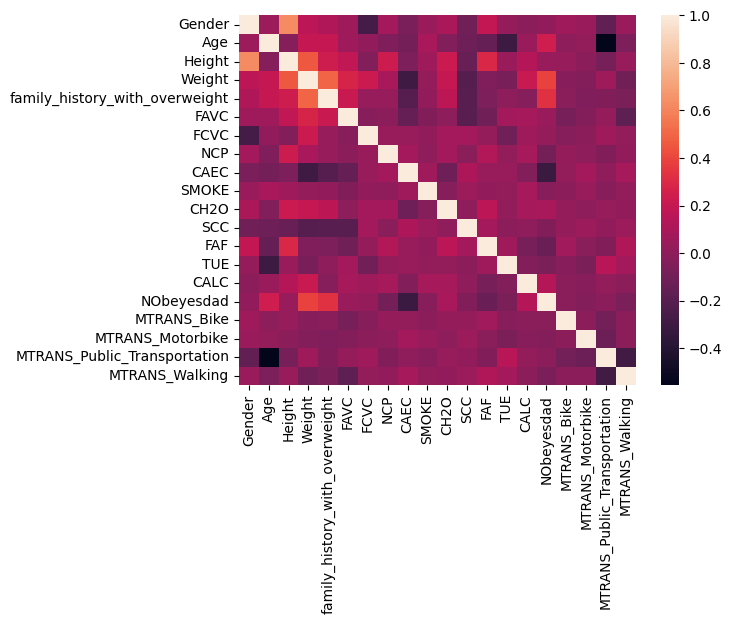

In [ ]:
sns.heatmap(df_encoded.corr(),annot=False)

The correlation matrix confirms expected relationships, such as family history, age and weight being associated with higher obesity levels. Highest positive correlation is between height and age, around 0.8, which is also within realms of expectations.

 Interestingly enough, one of the most negative correlations is between eating food between meals "CAEC" and obesity levels, which could lead to broader implications. However, correlations are generally low to moderate.

**MODELS**

**Training and evaluating a K-Nearest Neighbors classifier.**

In [ ]:
X = df_encoded.drop('NObeyesdad', axis=1)
y = df_encoded['NObeyesdad']

Separating features to the X and the target variable to y.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2,random_state=42,stratify=y)

  Splitting the data into training (80%) and testing (20%) sets with stratified sampling to preserve class proportions.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Standardizing features to have mean 0 and variance 1, fitting on training data and transforming both sets.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:",
      accuracy_score(y_test, y_pred_knn))

print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8014354066985646
              precision    recall  f1-score   support

           0       0.69      0.94      0.80        53
           1       0.55      0.46      0.50        57
           2       0.84      0.89      0.86        70
           3       0.88      0.97      0.92        60
           4       0.97      1.00      0.98        65
           5       0.77      0.62      0.69        55
           6       0.83      0.69      0.75        58

    accuracy                           0.80       418
   macro avg       0.79      0.79      0.79       418
weighted avg       0.80      0.80      0.79       418



Evaluating model performance by printing overall accuracy and per-class precision, recall, and F1-score.

Accuracy: 80.14%

Top performers: Obesity Type I (F1 = 0.98) and Overweight Level II (F1 = 0.92) are predicted very well.

Weakest performers: Normal Weight (F1 = 0.50) and Obesity Type II (F1 = 0.69) show the poorest performance, with recall particularly low (0.46 and 0.62, respectively), indicating these classes are frequently misclassified.

Overall: The model achieves solid baseline performance, but the class-specific disparities suggest that linear distance-based methods (like KNN) struggle to separate overlapping classes. This likely warrants exploring non-linear models like Random Forest or XGBoost to improve performance on the challenging middle categories. Before that, we will check the Decision Tree for full confidence.

**Evaluating K-Nearest Neighbours with confusion matrix.**

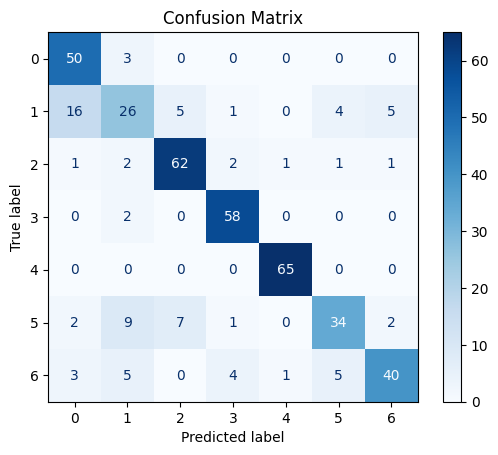

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_knn = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

Normal Weight (Class 1) is the most problematic—it is frequently misclassified across multiple other classes (both underweight and overweight). This explains its poor F1-score and suggests it exists in a feature space heavily overlapping with adjacent classes.

Obesity Type II (Class 5) is also frequently confused with Normal Weight, Overweight Level I, and Obesity Type III, indicating this class lacks clear distinguishing patterns in the KNN feature space.

Insufficient Weight (Class 0) and Obesity Type I (Class 4) are very well-predicted, likely because they are feature-distinct (very low weight vs. very high weight extremes).

**Performing cross-validation and evaluating overfitting for the KNN model.**

In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(knn,X,y,cv=5,scoring='accuracy')

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))
print("Std:", np.std(cv_scores))

CV Scores: [0.82057416 0.86842105 0.88968825 0.8705036  0.9088729 ]
Mean CV Accuracy: 0.8716119927024886
Std: 0.02943262518601879


In [ ]:
train_pred_knn = knn.predict(X_train_scaled)
test_pred_knn = knn.predict(X_test_scaled)

train_acc_knn = accuracy_score(y_train, train_pred_knn)
test_acc_knn = accuracy_score(y_test, test_pred_knn)

print("Train Accuracy:", train_acc_knn)
print("Test Accuracy :", test_acc_knn)
print("Difference    :", train_acc_knn - test_acc_knn)

Train Accuracy: 0.8651887357699221
Test Accuracy : 0.8014354066985646
Difference    : 0.06375332907135745


The cross-validation mean (87.16%) is higher than the test accuracy (80.14%), which is slightly unusual and may be due to the specific test split containing harder-to-predict samples. The gap between train and test accuracy (6.38%) indicates some overfitting, but not extreme. The low standard deviation across CV folds (0.029) suggests the model is stable and generalizes reasonably well. However, the drop from CV to test suggests the model may benefit from tuning (e.g., adjusting n_neighbors, distance weighting) or exploring more complex models to better capture the underlying patterns.

**Training and evaluating a K-Nearest Neighbors classifier.**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8325358851674641
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        53
           1       0.90      0.67      0.77        57
           2       0.77      0.96      0.85        70
           3       0.98      0.98      0.98        60
           4       1.00      0.98      0.99        65
           5       0.71      0.53      0.60        55
           6       0.56      0.69      0.62        58

    accuracy                           0.83       418
   macro avg       0.84      0.82      0.83       418
weighted avg       0.84      0.83      0.83       418



Accuracy: 83.25% — an improvement over KNN's 80.14%.

Top performers:

Overweight Level II (F1 = 0.98) and Obesity Type I (F1 = 0.99) — excellent. Insufficient Weight (F1 = 0.96) — very strong.

Weakest performers:

Obesity Type III (F1 = 0.62) — poor precision (0.56) and moderate recall (0.69), meaning many Type III cases are missed or misclassified, a metric worse than KNN. Obesity Type II (F1 = 0.60) — low recall (0.53), meaning over half of Type II cases are misclassified.
Normal Weight (F1 = 0.77) — improved over KNN but still the third weakest.

The Decision Tree with depth limitation shows better generalization than KNN for most classes, but the severe obesity classes (Type II and III) remain challenging. This further enforces the idea of using ensemble methods like Random Forest.


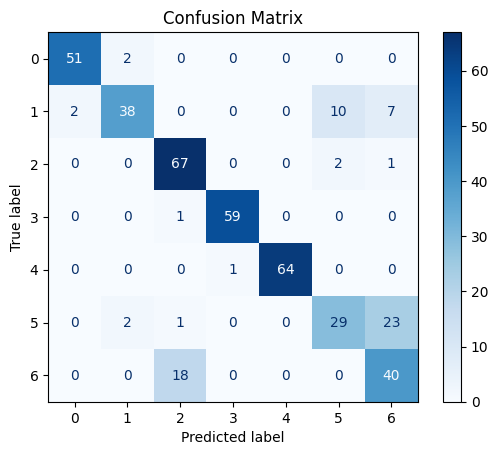

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

The Decision Tree significantly improves Normal Weight classification (38 vs 26 from KNN) but worsens Obesity Type II (29 vs 34), with many Type II cases being misclassified as Type II (23 cases), suggesting these two classes share similar feature patterns and the shallow tree cannot adequately separate them.

**Performing cross-validation and evaluating overfitting for the Decision Tree model.**

In [ ]:
cv_scores_dt=cross_val_score(dt,X,y,cv=5,scoring='accuracy')

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))
print("Std:", np.std(cv_scores))

CV Scores: [0.82057416 0.86842105 0.88968825 0.8705036  0.9088729 ]
Mean CV Accuracy: 0.8716119927024886
Std: 0.02943262518601879


In [ ]:
train_pred_dt = dt.predict(X_train)
test_pred_dt = dt.predict(X_test)

train_acc_dt = accuracy_score(y_train, train_pred_dt)
test_acc_dt = accuracy_score(y_test, test_pred_dt)

print("Train Accuracy:", train_acc_dt)
print("Test Accuracy :", test_acc_dt)
print("Difference    :", train_acc_dt - test_acc_dt)

Train Accuracy: 0.8448172558418214
Test Accuracy : 0.8325358851674641
Difference    : 0.012281370674357306


The Decision Tree shows stable, reliable performance across cross-validation folds with minimal overfitting. However, the mean CV accuracy (82.66%) is lower than KNN's CV mean (87.16%), despite the Decision Tree having higher test accuracy (83.25%). This suggests the Decision Tree may be more sensitive to the specific train/test split but generally performs better on unseen data.

**Training and evaluating Random Forest Classifier.**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9569377990430622
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        53
           1       0.84      0.95      0.89        57
           2       1.00      0.97      0.99        70
           3       0.98      1.00      0.99        60
           4       1.00      0.98      0.99        65
           5       0.93      0.91      0.92        55
           6       0.95      0.93      0.94        58

    accuracy                           0.96       418
   macro avg       0.96      0.96      0.96       418
weighted avg       0.96      0.96      0.96       418



The Random Forest model's overall performance, compared to KNN and Decision Tree, is stronger, achieving an accuracy of 95.69% with consistently high precision, recall, and F1-scores across all seven classes. The model demonstrates balanced performance, with both macro and weighted average scores of 0.96, indicating that it classifies all classes effectively. While Class 1 has a slightly lower precision (0.84), its high recall (0.95) suggests that the model successfully identifies most instances of that class. These results indicate that Random Forest provides a more robust and reliable classification performance than KNN and Decision Tree while maintaining strong generalization across the dataset.


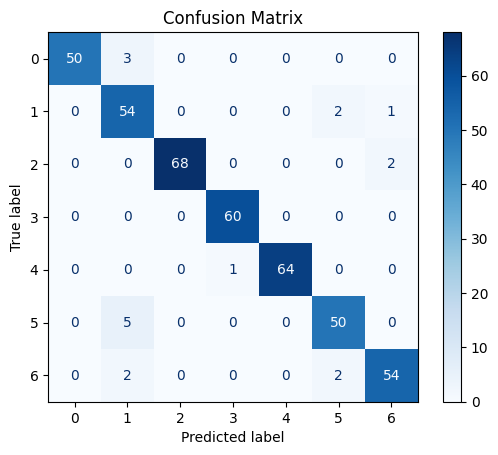

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows that the Random Forest model classified the majority of samples correctly, as indicated by the high values along the main diagonal. Perfect classification was achieved for Class 3 (Obesity Type 2), with all 60 samples correctly predicted. Most other classes also exhibited only a few misclassifications, such as Class 2 - Obesity Type 1 - (68/70 correctly classified) and Class 4 - Obesity Type 3 (64/65 correctly classified). The largest source of confusion occurred between Classes 1 and 5 (Normal Weight and Overweight level 1), where five samples of Class 5 were predicted as Class 1, contributing to the lower precision observed for Class 1. Overall, the confusion matrix demonstrates that the Random Forest model provides accurate and consistent classification across all seven classes, with only a small number of classification errors.

In [ ]:
cv_scores_rf = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

print("CV Scores:", cv_scores_rf)
print("Mean CV Accuracy:", np.mean(cv_scores_rf))

CV Scores: [0.715311   0.98803828 0.98081535 0.98561151 0.98321343]
Mean CV Accuracy: 0.930597914013287


The Random Forest model achieved a mean 5-fold cross-validation accuracy of 93.06%. While four folds produced consistently high accuracies (approximately 98-99%), one fold achieved 71.53%, lowering the overall average. This variation suggests that one subset of the data was more challenging to classify; however, the consistently strong performance across the remaining folds indicates that the model generalizes well and maintains robust predictive performance.

In [ ]:
train_pred_rf = rf.predict(X_train)
test_pred_rf = rf.predict(X_test)

train_acc_rf = accuracy_score(y_train, train_pred_rf)
test_acc_rf = accuracy_score(y_test, test_pred_rf)

print("Train Accuracy:", train_acc_rf)
print("Test Accuracy :", test_acc_rf)
print("Difference    :", train_acc_rf - test_acc_rf)

Train Accuracy: 1.0
Test Accuracy : 0.9569377990430622
Difference    : 0.0430622009569378


The Random Forest model achieved a training accuracy of 100% and a test accuracy of 95.69%, resulting in a difference of 4.31% between the training and testing performances. This gap indicates a mild overfitting.

**Training and evaluating XGBoost.**

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss')

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print("XGBoost Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9808612440191388
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.96      0.96      0.96        57
           2       0.99      0.99      0.99        70
           3       0.98      1.00      0.99        60
           4       1.00      0.98      0.99        65
           5       0.96      0.95      0.95        55
           6       0.97      0.98      0.97        58

    accuracy                           0.98       418
   macro avg       0.98      0.98      0.98       418
weighted avg       0.98      0.98      0.98       418



The XGBoost model achieved an accuracy of 98.09%, demonstrating excellent classification performance across all seven classes. Precision, recall, and F1-scores were consistently high, with macro and weighted averages of 0.98, indicating balanced performance regardless of class size. Class 0 was classified perfectly, achieving precision, recall, and F1-score of 1.00, while the remaining classes also achieved F1-scores ranging from 0.95 to 0.99. The slightly lower precision and recall for Classes 1, 5, and 6 indicate only a small number of misclassifications. Overall, these results show that the XGBoost model provides highly accurate and reliable classification with strong performance across all classes.

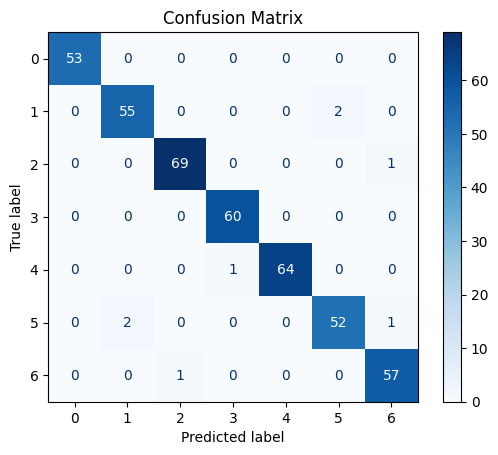

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

The confusion matrix demonstrates that the XGBoost model achieved excellent classification performance, with nearly all predictions concentrated along the main diagonal, indicating correct classifications. Insufficient Weight and Obesity Type II were classified perfectly, with all 53 and 60 samples correctly identified, respectively. The remaining categories also exhibited very few misclassifications. The most noticeable confusion occurred between Normal Weight and Overweight Level I, where two Normal Weight samples were predicted as Overweight Level I, and two Overweight Level I samples were predicted as Normal Weight. Minor misclassifications were also observed between Obesity Type I and Overweight Level II, Overweight Level I and Overweight Level II, and Obesity Type III and Obesity Type II, each involving only one sample. Overall, the confusion matrix confirms the model's high classification accuracy (98.09%) and demonstrates consistent and reliable performance across all seven weight categories.

In [ ]:
cv_scores_xgb = cross_val_score(xgb, X, y, cv=5, scoring='accuracy')

print("CV Scores:", cv_scores_xgb)
print("Mean CV Accuracy:", np.mean(cv_scores_xgb))

CV Scores: [0.83732057 0.98325359 0.98800959 0.98800959 0.98800959]
Mean CV Accuracy: 0.9569205879315685


The XGBoost model achieved a mean 5-fold cross-validation accuracy of 95.69%, which is higher than the cross-validation accuracies obtained by the previously evaluated models. While the first fold produced a lower accuracy (83.73%), the remaining four folds consistently achieved accuracies of approximately 98.8%, demonstrating strong stability and excellent generalization across different data splits.

In [ ]:
train_pred_xgb = xgb.predict(X_train)
test_pred_xgb = xgb.predict(X_test)

train_acc_xgb = accuracy_score(y_train, train_pred_xgb)
test_acc_xgb = accuracy_score(y_test, test_pred_xgb)

print("Train Accuracy:", train_acc_xgb)
print("Test Accuracy :", test_acc_xgb)
print("Difference    :", train_acc_xgb - test_acc_xgb)

Train Accuracy: 1.0
Test Accuracy : 0.9808612440191388
Difference    : 0.019138755980861233


The XGBoost model achieved a training accuracy of 100% and a test accuracy of 98.09%, resulting in a difference of only 1.91% between the training and testing performances. This very small gap indicates that the model generalizes exceptionally well to unseen data while maintaining excellent predictive performance. Although the perfect training accuracy suggests that the model fits the training data completely, the minimal difference between the training and test accuracies indicates only negligible overfitting and demonstrates the model's strong robustness and reliability.

In [ ]:
comparison_df = pd.DataFrame({
    "Model": [
        "KNN",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Train Accuracy": [
        train_acc_knn,
        train_acc_dt,
        train_acc_rf,
        train_acc_xgb
    ],

    "Test Accuracy": [
        test_acc_knn,
        test_acc_dt,
        test_acc_rf,
        test_acc_xgb],
    "Train-Test Difference": [
        train_acc_knn - test_acc_knn,
        train_acc_dt - test_acc_dt,
        train_acc_rf - test_acc_rf,
        train_acc_xgb - test_acc_xgb],
    "CV Accuracy": [
        np.mean(cv_scores),
        np.mean(cv_scores_dt),
        np.mean(cv_scores_rf),
        np.mean(cv_scores_xgb)]})

comparison_df = comparison_df.round(4)
comparison_df

,Model,Train Accuracy,Test Accuracy,Train-Test Difference,CV Accuracy
0,KNN,0.8652,0.8014,0.0638,0.8716
1,Decision Tree,0.8448,0.8325,0.0123,0.8266
2,Random Forest,1.0000,0.9569,0.0431,0.9306
3,XGBoost,1.0000,0.9809,0.0191,0.9569


Among 4 classification models (KNN, DecisionTree, RandomForest, XGBoost), there is a striking difference between DecisionTree and KNN & RandomForest and XGBoost. Ensemble Methods significantly outperform single models. Among them the XGBoost is the most accurate and reliable at predictions. Therefore, it was decided that XGBoost is the recommended model for the Obesity Classification dataset.
